# King County House Price Prediction

## Dataset Description

This dataset comprises real estate sales prices and related metrics for King County, WA. Dates range from 2014 to 2015.


| Variable      | Description                                |
| ------------- | ------------------------------------------ |
| id            | House identification number                |
| date          | Date of sale                               |
| price         | Sale price (prediction target variable)    |
| bedrooms      | Number of bedrooms                         |
| bathrooms     | Number of bathrooms                        |
| sqft_living   | Square footage of the home                 |
| sqft_living15 | Average living area of the 15 nearest neighbours (sqft) |
| sqft_lot      | Square footage of the lot                  |
| sqft_lot15    | Average lot size of the 15 nearest neighbours (sqft) |
| floors        | Total floors (levels) in house             |
| waterfront    | Waterfront property (1 = yes, 0 = no)      |
| view          | Quality of the view, rated 0 to 4          |
| condition     | Overall dwelling condition                 |
| grade         | House grade (King County grading system)   |
| sqft_above    | Square footage of the house above ground   |
| sqft_basement | Square footage of the basement             |
| yr_built      | Year built                                 |
| yr_renovated  | Year of house renovation                   |
| zipcode       | Zip code                                   |
| lat           | Latitude coordinate                        |
| long          | Longitude coordinate                       |




## Libraries
To begin, I import the necessary libraries, along with `clean()` from `cleaning.py` and the two plotting functions from `plots.py`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate

from cleaning import DATA_PATH, clean
from plots import waterfront_boxplot, sqft_scatter

%matplotlib inline

## Reading Dataset

Next, I read in the dataset .csv file (`DATA_PATH`, set in `cleaning.py`) to a Pandas data frame with the `read_csv()` method. I keep this raw copy for the checks below and clean it in the Data Wrangling section.

In [2]:
raw = pd.read_csv(DATA_PATH)

Displaying the leading 5 rows of the data frame with the `head()` method:

In [3]:
raw.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Summary Statistics                                                                                                                                                                       

I am interested in getting an overview of the dataset. Firstly, I will look at the data types of each column using the Pandas `dtypes` property


In [4]:
raw.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

I use the Pandas `describe()` method to return summary statistics of each numerical column. 

In [5]:
raw.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Data Wrangling


Checking for missing (NaN) values using `isnull().sum()`:


In [6]:
raw.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

There are no blank cells, but missing values can also be recorded as 0. A few homes are listed with 0 bedrooms or 0 bathrooms, including large, expensive homes where a count of 0 can't be right:

In [7]:
print('Homes with 0 bedrooms:', (raw['bedrooms'] == 0).sum())
print('Homes with 0 bathrooms:', (raw['bathrooms'] == 0).sum())

zero_counts = (raw['bedrooms'] == 0) | (raw['bathrooms'] == 0)
raw.loc[zero_counts, ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'grade']].sort_values('price', ascending=False).head()

Homes with 0 bedrooms: 13
Homes with 0 bathrooms: 10


,price,bedrooms,bathrooms,sqft_living,grade
6994,1295650.0,0,0.0,4810,12
875,1095000.0,0,0.0,3064,7
10481,484000.0,1,0.0,690,7
3119,380000.0,0,0.0,1470,8
9773,355000.0,0,0.0,2460,8


One home is also listed with 33 bedrooms but only 1,620 sq ft and 1.75 bathrooms, which is almost certainly a typo for 3:

In [8]:
raw.loc[raw['bedrooms'] == 33, ['price', 'bedrooms', 'bathrooms', 'sqft_living']]

,price,bedrooms,bathrooms,sqft_living
15870,640000.0,33,1.75,1620


Now I want to clean up the dataset, using the `clean()` function in `cleaning.py`. It drops the **"id"** column, as it is unnecessary for data analysis, and converts the date column from raw string to datetime format. It then treats the 0 bedroom and bathroom counts and the 33-bedroom typo as missing, and fills the missing **"bedrooms"** and **"bathrooms"** values with each column's median. The median suits these columns better than the mean: it isn't pulled by extreme values, and it fills in a realistic whole number of bedrooms instead of a fraction.

In [9]:
data = clean(raw)

# view data
data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,2014-12-09,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2015-02-25,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2014-12-09,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2015-02-18,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,2014-05-21,360000.0,3.0,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,2015-02-23,400000.0,4.0,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,2014-06-23,402101.0,2.0,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,2015-01-16,400000.0,3.0,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


Checking that no 0 or 33 values remain and that nothing is missing, to verify the imputation:

In [10]:
print('Homes with 0 bedrooms:', (data['bedrooms'] == 0).sum())
print('Homes with 0 bathrooms:', (data['bathrooms'] == 0).sum())
print('Homes with 33 bedrooms:', (data['bedrooms'] == 33).sum())
print('Missing values:', data.isnull().sum().sum())

Homes with 0 bedrooms: 0
Homes with 0 bathrooms: 0
Homes with 33 bedrooms: 0
Missing values: 0


## Exploratory Data Analysis


#### Determining the total count of houses with each unique number of floors.

In [11]:
pd.DataFrame(data['floors'].value_counts()).reset_index()

,floors,count
0,1.0,10680
1,2.0,8241
2,1.5,1910
3,3.0,613
4,2.5,161
5,3.5,8


For houses with an integer number of floors, houses with a greater number of floors are less common. The same is seen for houses with non-integer numbers of floors. Note: a half-floor indicates a floor (typically upper) that is considerably smaller than the other, main floor(s).

#### Determining whether houses with or without a waterfront view have a greater number of price outliers.
Plotting a box plot with `waterfront_boxplot()` from `plots.py`, which uses the Seaborn `boxplot()` function:

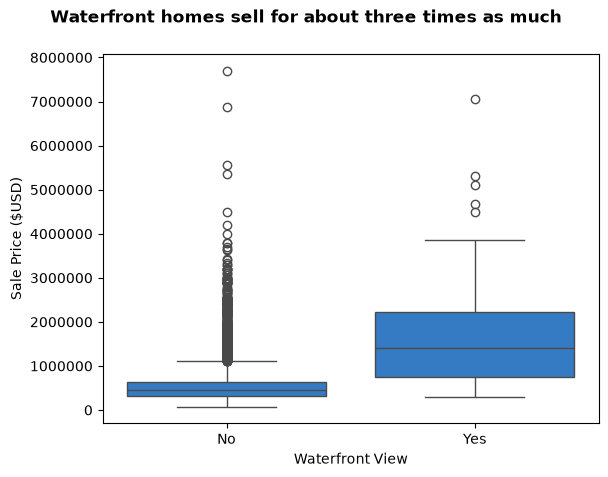

In [12]:
waterfront_boxplot(data);

As evident in the box plot above, houses without a waterfront view have a greater number of price outliers. The median sale price is ~$450,000 for dwellings without a waterfront view, and ~$1,400,000 for those with a waterfront view. 

#### Determining the direction of correlation between **"sqft_living"** and price.
Plotting a scatter plot with `sqft_scatter()` from `plots.py`, which uses the Seaborn `regplot()` function:

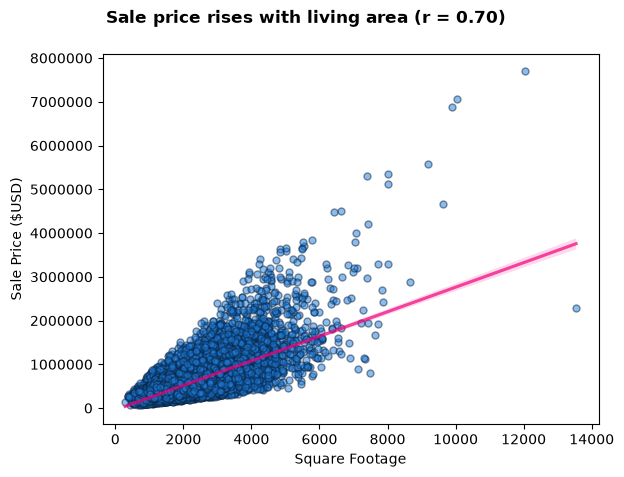

In [13]:
sqft_scatter(data);

As the scatter plot shows, the square footage and sale price appear to be positively correlated.

#### Determining the feature most closely correlated with price.


In [14]:
data.corr(numeric_only=True)['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525714
view             0.397293
sqft_basement    0.323816
bedrooms         0.316028
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

Square footage of the house is most closely correlated with sale price, with a correlation coefficient of 0.702.

## Model Development


To estimate a linear regression model to predict sale price using longitude, I use the `LinearRegression()` function and the longitudinal coordinate **"long"**. The `.score()` method is used to calculate the R-squared value.

In [15]:
X = data[['long']]
y = data['price']
lm = LinearRegression()
print("R-Squared:", lm.fit(X, y).score(X, y))

R-Squared: 0.0004676943014898516


Similarly, to estimate a linear regression model to predict sale price using the square footage of a house, I use the `LinearRegression()` function and the **"sqft_living"** feature. Again, the `.score()` method is used to calculate the R-squared value.

In [16]:
X = data[['sqft_living']]
lm = LinearRegression()
lm.fit(X, y)
print('Predicted values:', lm.predict(X))
print('R-Squared:', lm.score(X, y))

Predicted values: [287555.06702452 677621.82640197 172499.40418656 ... 242655.29616092
 405416.96554144 242655.29616092]
R-Squared: 0.4928532179037931


Fitting a linear regression model to predict the sale price using a list of features, then calculating the R-squared value.

For house size, the list uses **"sqft_living"** only. In every row, it is exactly the sum of **"sqft_above"** and **"sqft_basement"**:

In [17]:
print('sqft_living = sqft_above + sqft_basement in every row:',
      (data['sqft_above'] + data['sqft_basement'] == data['sqft_living']).all())

sqft_living = sqft_above + sqft_basement in every row: True


So each of the three adds no information beyond the other two, and including all three would make the individual size coefficients meaningless. Keeping **"sqft_basement"** as well made no difference to the linear Ridge model, and raised the polynomial Ridge model's cross-validated R-squared (see Cross-Validation below) only from 0.740 to 0.744, so I keep **"sqft_living"** on its own for a simpler model.

In [18]:
features = ["floors", "waterfront", "lat", "bedrooms", "view", "bathrooms", "grade", "sqft_living", "sqft_living15", "sqft_lot", "sqft_lot15"]

In [19]:
X = data[features]
lm = LinearRegression().fit(X, y)
print('Predicted values:', lm.predict(X))
print('R-Squared:', lm.score(X, y))

Predicted values: [283678.81766127 666399.25518286 310565.26422222 ... 306883.36919107
 430795.0691711  307018.29503899]
R-Squared: 0.6590903313775713


Next, I define the three pipelines used in the rest of the notebook. Each one scales the features first. `poly_linear` adds second-order polynomial terms before a linear regression; `ridge_linear` and `ridge_poly` are the Ridge versions used in Model Evaluation and Refinement below:

In [20]:
poly_linear = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression()),
])
ridge_linear = Pipeline([
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=0.1)),
])
ridge_poly = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=0.1)),
])

Fitting the `poly_linear` pipeline to predict the `price` using the features in the list `features`, and calculating the R-squared:

In [21]:
poly_linear.fit(X, y)
print('R-Squared:', poly_linear.score(X, y))

R-Squared: 0.756620648906148


## Model Evaluation and Refinement


Now I will evaluate the linear regression with a ridge regression object. The data is first split into training and testing sets:

In [22]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=1)

print("Test sample count:", x_test.shape[0])
print("Training sample count:", x_train.shape[0])

Test sample count: 3242
Training sample count: 18371


Ridge's penalty depends on the size of each coefficient, which depends on the units of its feature, so the `ridge_linear` pipeline standardizes the features first. Fitting the pipeline on the training data fits the scaler on the training set only, and the same scaling is then applied to the test set, so no test data leaks into preprocessing. I fit it using the training data and calculate the R-squared value with the test data:

In [23]:
ridge_linear.fit(x_train, y_train)
print('R-squared:', ridge_linear.score(x_test, y_test))

R-squared: 0.6488371414882441


Finally, I use the `ridge_poly` pipeline, which adds a second order polynomial transform after the scaling step. Because the features are scaled first, each one is centred before it is squared or multiplied, which keeps the Ridge fit numerically stable. The test data is used to calculate the R-squared:

In [24]:
ridge_poly.fit(x_train, y_train)
print('R-squared:', ridge_poly.score(x_test, y_test))

R-squared: 0.7223599750858909


## Cross-Validation
A single train/test split can give a lucky (or unlucky) score. To check whether the polynomial Ridge model's improvement holds up, I compare both Ridge pipelines with 5-fold cross-validation using `cross_val_score()`. Because the scaling and polynomial transform are inside the pipelines, they are refit inside every fold.

In [25]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for name, model in [('Ridge (linear)', ridge_linear), ('Ridge (degree-2 polynomial)', ridge_poly)]:
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(f'{name}: mean R-squared = {scores.mean():.3f} (std {scores.std():.3f})')
    print('    per fold:', scores.round(3))

Ridge (linear): mean R-squared = 0.658 (std 0.007)
    per fold: [0.647 0.67  0.655 0.659 0.659]
Ridge (degree-2 polynomial): mean R-squared = 0.740 (std 0.021)
    per fold: [0.768 0.732 0.747 0.706 0.746]


After the polynomial transform, the R-squared value increases. This suggests the data is a better fit to a second-order polynomial model rather than the initial linear model. 

Although an increase in R-squared often indicates an improved fit, it isn't conclusive on its own as more features can inflate the score without adding predictive power. 

However, the 5-fold cross-validation confirms the improvement is real. The polynomial model's mean R-squared (0.740, ± 0.021) stays above the linear model's (0.658, ± 0.007) across all folds, indicating the gain holds up rather than being the product of one favourable train/test split.

## Improving the Model
The models above leave out most of the location data, and they predict raw prices even though price is heavily right-skewed. In this section I add location, fit on log price, and check whether the Ridge alpha matters. Every model is scored with the same 5-fold cross-validation as above, in dollars. Alongside R-squared, I report the mean absolute error, since R-squared is based on squared errors, which the most expensive homes dominate.

### Location
**"lat"** is already in the feature list, but **"long"** and **"zipcode"** are not. I add **"long"** to the polynomial features, so the model can use latitude and longitude together. Zipcode is stored as a number but is really a category (98004 isn't "more" than 98001), so I one-hot encode its 70 values with `OneHotEncoder`. The zipcode columns go alongside the polynomial terms rather than through them, which would create thousands of zipcode-by-zipcode columns. A `ColumnTransformer` applies each step to its own columns:

In [26]:
location_features = features + ['long']

ridge_location = Pipeline([
    ('prep', ColumnTransformer([
        ('numeric', Pipeline([
            ('scale', StandardScaler()),
            ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
        ]), location_features),
        ('zipcode', OneHotEncoder(), ['zipcode']),
    ])),
    ('model', Ridge(alpha=0.1)),
])

### Log price
Fitting on log price makes the model's errors proportional to price, so a $50,000 miss on a $300,000 home counts for more than the same miss on a $3,000,000 home. Taking the log also removes most of the skew:

In [27]:
print('Skewness of price:', round(y.skew(), 2))
print('Skewness of log price:', round(np.log(y).skew(), 2))

Skewness of price: 4.02
Skewness of log price: 0.43


`TransformedTargetRegressor` fits the model on log price and converts its predictions back to dollars with `np.exp`, so the scores stay comparable with the ones above. One side effect: converting back from log gives the typical (median) price for a home's features rather than the average, so predictions run slightly low on average.

In [28]:
ridge_location_log = TransformedTargetRegressor(regressor=ridge_location, func=np.log, inverse_func=np.exp)

Comparing the polynomial Ridge model from above with the two new versions:

In [29]:
location_columns = location_features + ['zipcode']
models = [
    ('Ridge (degree-2 polynomial)', ridge_poly, features),
    ('+ long and zipcode', ridge_location, location_columns),
    ('+ long and zipcode, log price', ridge_location_log, location_columns),
]

for name, model, columns in models:
    scores = cross_validate(model, data[columns], y, cv=kf, scoring=('r2', 'neg_mean_absolute_error'))
    print(f"{name}: mean R-squared = {scores['test_r2'].mean():.3f} (std {scores['test_r2'].std():.3f}), "
          f"mean absolute error = ${-scores['test_neg_mean_absolute_error'].mean():,.0f}")

Ridge (degree-2 polynomial): mean R-squared = 0.740 (std 0.021), mean absolute error = $116,328
+ long and zipcode: mean R-squared = 0.862 (std 0.011), mean absolute error = $81,350
+ long and zipcode, log price: mean R-squared = 0.870 (std 0.020), mean absolute error = $73,022


### Ridge alpha
Alpha has been fixed at 0.1 throughout. To check whether it matters, I score the final model with a range of values:

In [30]:
for alpha in [0.01, 0.1, 1, 10, 100, 1000]:
    model = clone(ridge_location_log).set_params(regressor__model__alpha=alpha)
    scores = cross_val_score(model, data[location_columns], y, cv=kf, scoring='r2')
    print(f'alpha = {alpha}: mean R-squared = {scores.mean():.3f}')

alpha = 0.01: mean R-squared = 0.870
alpha = 0.1: mean R-squared = 0.870
alpha = 1: mean R-squared = 0.870
alpha = 10: mean R-squared = 0.870
alpha = 100: mean R-squared = 0.854
alpha = 1000: mean R-squared = 0.807


Adding **"long"** and zipcode raises the cross-validated R-squared from 0.740 to 0.862 and cuts the mean absolute error from $116,328 to $81,350, the largest improvement in this notebook. Fitting on log price then raises R-squared only slightly, to 0.870, but cuts the mean absolute error further, to $73,022, so its benefit shows up in the size of the errors rather than in R-squared.

Alpha makes no difference between 0.01 and 10, and larger values make the model worse, so I keep it at 0.1.